# Titanic Dataset - Feature Engineering

## Objective
To create new meaningful features from existing data that can improve analysis and insights about passenger survival.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("C:\\Users\\lenovo\\OneDrive\\Desktop\\rohan academical inventoiry\\web development\\internship\\horizon projects\\project 1 - EDA titanic\\data\\processed\\cleaned_titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


## What is Feature Engineering?

Feature Engineering means creating new useful variables from existing data to improve analysis.

Instead of only using raw columns, we build smarter features that reveal hidden patterns.

In [3]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1


## Feature: FamilySize

We created a new feature called FamilySize:

FamilySize = SibSp + Parch + 1

Where:
- SibSp = siblings/spouse aboard
- Parch = parents/children aboard
- +1 = the passenger themselves

This helps us understand if traveling alone or with family affected survival.

In [4]:
df['FamilySize'].value_counts()

FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

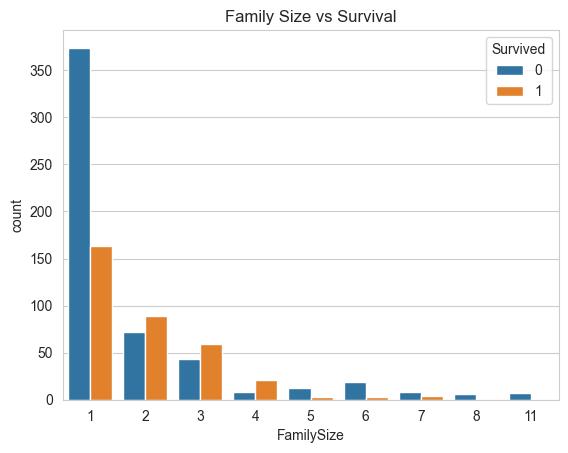

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='FamilySize', hue='Survived', data=df)

plt.title("Family Size vs Survival")
plt.show()

## Insight: Family Size vs Survival

Passengers with small family sizes (1–3 members) had better survival chances.

Very large families had lower survival rates, possibly due to difficulty in evacuation.

In [6]:
df['IsAlone'] = 0

df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1


## Feature: IsAlone

We created a binary feature:
- 1 = Passenger is alone
- 0 = Passenger is with family

This helps analyze whether solo travelers had different survival chances.

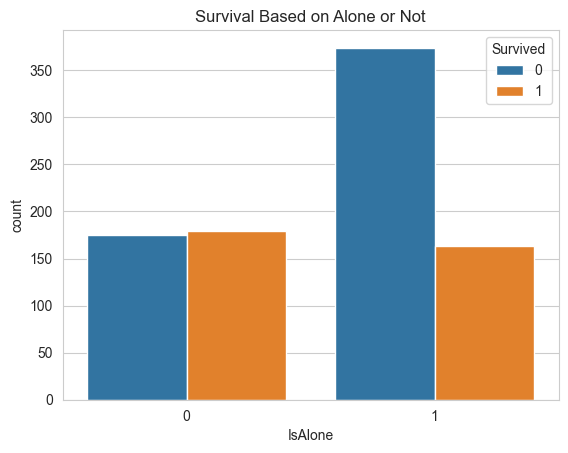

In [7]:
sns.countplot(x='IsAlone', hue='Survived', data=df)

plt.title("Survival Based on Alone or Not")
plt.show()

## Insight: IsAlone vs Survival

Passengers who were not alone had better survival chances compared to solo travelers.

This suggests family presence may have influenced survival behavior.

In [8]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

df.head()

<>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
C:\Users\lenovo\AppData\Local\Temp\ipykernel_7368\3313432086.py:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1,Mr


## Feature: Title Extraction

We extracted titles from passenger names (Mr, Mrs, Miss, etc.)

Titles can help represent social status, which may influence survival chances.

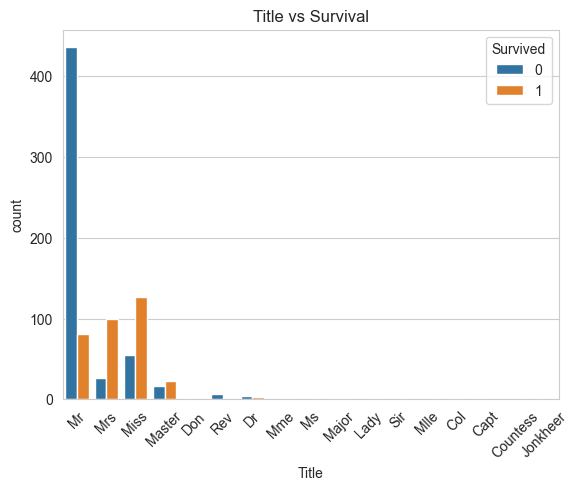

In [9]:
sns.countplot(x='Title', hue='Survived', data=df)

plt.xticks(rotation=45)
plt.title("Title vs Survival")
plt.show()

## Insight: Title vs Survival

Women-related titles like Miss and Mrs had higher survival rates.

Rare titles may indicate higher social status or unique groups.

In [10]:
df.to_csv("../data/processed/feature_engineered_titanic.csv", index=False)

## Feature Engineering Summary

We created new features:

- FamilySize (SibSp + Parch + 1)
- IsAlone (binary feature)
- Title (extracted from Name)

These features help uncover deeper patterns in survival analysis.